# 02 - Análise Exploratória de Dados

## 1. Importação das bibliotecas e leitura dos dados

Nesta etapa, são importadas as bibliotecas utilizadas ao longo da análise exploratória e carregado o dataset enriquecido gerado na etapa anterior do projeto.

O conjunto de dados utilizado contém informações individuais dos alunos, características territoriais e socioeconômicas dos municípios e indicadores agregados do contexto escolar.

O dataset carregado possui:

- **57.782 registros**
- **36 variáveis**

Essa etapa garante que a base enriquecida esteja disponível corretamente antes do início das validações estruturais e análises estatísticas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

BASE_DIR = Path("..")
GOLD_DIR = BASE_DIR / "data" / "gold"

DATASET_PATH = GOLD_DIR / "gold_dataset_enriquecido.parquet"

df = pd.read_parquet(DATASET_PATH)

print("Dataset carregado com sucesso.")
print("Shape:", df.shape)

Dataset carregado com sucesso.
Shape: (57782, 36)


## 2. Validação estrutural inicial

Antes de realizar qualquer análise exploratória, é necessário verificar a consistência estrutural do dataset.

Essa validação inicial busca identificar possíveis problemas relacionados a:

- quantidade de registros e variáveis;
- tipos de dados;
- duplicidades;
- cobertura temporal;
- consistência da variável alvo;
- presença de valores ausentes.

Essas verificações são importantes para garantir que as análises posteriores sejam realizadas sobre uma base consistente e confiável.

### 2.1 Dimensão e tipos de dados

O dataset apresenta **57.782 linhas e 36 colunas**.

A inspeção dos tipos de dados mostra a presença de variáveis numéricas, categóricas e identificadores, compatíveis com a natureza heterogênea das informações utilizadas no projeto.

As variáveis incluem dados individuais dos alunos, identificadores territoriais, informações educacionais e atributos provenientes das fontes externas utilizadas no enriquecimento.

In [2]:
print(f"Total de Linhas -> {df.shape[0]}")
print(f"Total de Colunas -> {df.shape[1]}")

Total de Linhas -> 57782
Total de Colunas -> 36


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 57782 entries, 0 to 57781
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ano                                  57782 non-null  Int64  
 1   id_municipio                         57782 non-null  string 
 2   id_municipio_nome                    57782 non-null  string 
 3   id_escola                            57782 non-null  string 
 4   id_aluno                             57782 non-null  string 
 5   caderno                              57782 non-null  int64  
 6   serie                                57782 non-null  string 
 7   rede                                 57782 non-null  string 
 8   presenca                             57782 non-null  string 
 9   preenchimento_caderno                57782 non-null  string 
 10  alfabetizado                         57782 non-null  string 
 11  proficiencia                         48

### 2.2 Verificação de duplicidades

A granularidade da base corresponde a registros individuais de alunos por ano.

Como o mesmo `id_aluno` pode aparecer em anos diferentes, a verificação de duplicidade foi realizada considerando a chave composta:

`ano + id_aluno`

Não foram identificadas duplicidades nessa chave.

Também não foram encontradas linhas completamente duplicadas no dataset.

Esse resultado indica que a base mantém uma granularidade consistente para as análises individuais.

In [4]:
duplicidades = df.duplicated(subset=["ano", "id_aluno"]).sum()

print(f"Duplicidades por Ano + Id_aluno -> {duplicidades}")

Duplicidades por Ano + Id_aluno -> 0


In [5]:
print(f"Linhas completamente duplicadas -> {df.duplicated().sum()}")

Linhas completamente duplicadas -> 0


### 2.3 Cobertura temporal

O dataset contém registros referentes aos anos de **2023 e 2024**.

A distribuição dos registros é:

- **2023:** 28.295 observações
- **2024:** 29.487 observações

A quantidade de registros é relativamente equilibrada entre os dois anos, permitindo comparações temporais sem grande concentração em apenas um período.

In [6]:
print(df["ano"].value_counts().sort_index())

ano
2023    28295
2024    29487
Name: count, dtype: Int64


### 2.4 Validação da variável alvo

A variável `alfabetizado` representa o desfecho principal do projeto e será posteriormente utilizada como variável alvo no modelo de classificação supervisionada.

A distribuição observada foi:

- **Não alfabetizado:** 29.535 alunos — 51,11%
- **Alfabetizado:** 28.247 alunos — 48,89%

Não foram identificados valores ausentes na variável alvo.

A distribuição das classes é bastante equilibrada, o que é favorável para a etapa de modelagem, pois reduz a necessidade de técnicas específicas para tratamento de forte desbalanceamento de classes.

In [7]:
print(f"Valores únicos do target -> {df['alfabetizado'].unique()}")

print(f"\nDistribuição:")
print(df['alfabetizado'].value_counts())

print("\nDistribuição em Percentual:")
print(df['alfabetizado'].value_counts(normalize=True).mul(100).round(2))

Valores únicos do target -> <ArrowStringArray>
['Não', 'Sim']
Length: 2, dtype: string

Distribuição:
alfabetizado
Não    29535
Sim    28247
Name: count, dtype: int64[pyarrow]

Distribuição em Percentual:
alfabetizado
Não    51.11
Sim    48.89
Name: proportion, dtype: double[pyarrow]


### 2.5 Análise inicial de valores ausentes

A análise de valores ausentes revelou diferentes níveis de cobertura entre as variáveis.

As maiores proporções de ausência foram identificadas em:

- `meta_municipio_ano`: aproximadamente 57,18%
- `meta_uf_ano`: aproximadamente 57,18%
- `proficiencia`: aproximadamente 16,88%
- `peso_aluno`: aproximadamente 16,88%
- `percentual_participacao`: aproximadamente 13,53%

As demais variáveis apresentam cobertura elevada, com ausência inexistente ou residual.

Esses resultados serão utilizados posteriormente para definir quais variáveis serão mantidas nas análises principais e quais deverão ser descartadas por baixa cobertura, baixa relevância analítica ou risco de vazamento de informação.

In [8]:
resumo_final = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True)
})

display(resumo_final)

,tipo,nulos,pct_nulos,valores_unicos
ano,Int64,0,0.00,2
id_municipio,string,0,0.00,4591
id_municipio_nome,string,0,0.00,4397
id_escola,string,0,0.00,24346
id_aluno,string,0,0.00,57449
caderno,int64,0,0.00,4
serie,string,0,0.00,1
rede,string,0,0.00,2
presenca,string,0,0.00,2
preenchimento_caderno,string,0,0.00,2


### 2.6 Definição das variáveis utilizadas na análise

Após a avaliação inicial da qualidade dos dados, algumas variáveis foram removidas da base utilizada no EDA principal.

As colunas excluídas foram:

- `serie`: removida por apresentar apenas um único valor em toda a base, não contribuindo para diferenciação dos registros;
- `meta_municipio_ano`: removida devido à elevada proporção de valores ausentes;
- `meta_uf_ano`: removida devido à elevada proporção de valores ausentes;
- `proficiencia`: removida por apresentar potencial vazamento de informação em relação à variável alvo `alfabetizado`;
- `peso_aluno`: removida por não representar uma característica explicativa direta do fenômeno analisado;
- `percentual_participacao`: removida por apresentar valores ausentes e menor relevância frente ao conjunto de variáveis já disponíveis.

Após essa etapa, o dataset passou de **36 para 29 variáveis**, mantendo os **57.782 registros** originais.

A remoção foi realizada apenas na cópia utilizada para análise (`df_eda`), preservando o dataset enriquecido original.

In [9]:
colunas_remover = ["serie", "meta_municipio_ano", "meta_uf_ano", "proficiencia", "peso_aluno", "percentual_participacao"]

df_eda = df.drop(columns=colunas_remover).copy()

print(f"Shape original -> {df.shape}")
print(f"Shape após a remoção das columas -> {df_eda.shape}")

print("\nColunas que foram removidas")
for colunas in colunas_remover:
    print(f"-> {colunas}")

Shape original -> (57782, 36)
Shape após a remoção das columas -> (57782, 30)

Colunas que foram removidas
-> serie
-> meta_municipio_ano
-> meta_uf_ano
-> proficiencia
-> peso_aluno
-> percentual_participacao


### 2.7 Tratamento final de valores ausentes

Após a remoção das variáveis previamente definidas, permaneceram apenas valores ausentes residuais no dataset.

A aplicação de `dropna()` resultou em:

- **57.782 registros antes do tratamento**
- **57.712 registros após o tratamento**
- **70 registros removidos**
- **0,12% de perda da base**

Como a proporção removida foi muito pequena, considerou-se adequada a exclusão desses registros.

Ao final dessa etapa, o dataset utilizado no EDA ficou totalmente livre de valores ausentes.

In [10]:
linhas_antes = len(df_eda)

df_eda_sem_nulos = df_eda.dropna().copy()

linhas_depois = len(df_eda_sem_nulos)
percentual = ((linhas_antes - linhas_depois) / linhas_antes * 100)

print(f"Linhas antes -> {linhas_antes}")
print(f"Linhas depois -> {linhas_depois}")
print(f"Linhas que foram removidas -> {linhas_antes - linhas_depois}")
print(f"Percentual removido -> {percentual:.2f}%")

Linhas antes -> 57782
Linhas depois -> 57712
Linhas que foram removidas -> 70
Percentual removido -> 0.12%


In [11]:
df_eda = df_eda.dropna()
print(f"Total de nulos -> {df_eda.isna().sum().sum()}")

Total de nulos -> 0


### 2.8 Conclusão da preparação para o EDA

A etapa de preparação e validação do dataset foi concluída com sucesso.

A base utilizada nas análises exploratórias apresenta:

- ausência de duplicidades;
- variável alvo completa e aproximadamente balanceada;
- cobertura temporal entre 2023 e 2024;
- remoção de variáveis com baixa utilidade analítica, alta ausência ou risco de vazamento de informação;
- tratamento residual de valores ausentes;
- preservação de aproximadamente 99,88% dos registros originais.

Com isso, o dataset encontra-se em condições adequadas para o início das análises exploratórias de distribuições, padrões, associações e relações entre as variáveis e o indicador de alfabetização.

## 3. Análise da variável alvo

A variável `alfabetizado` representa o desfecho principal do projeto e será utilizada como variável alvo na etapa de modelagem supervisionada.

Nesta seção, sua distribuição é analisada com o objetivo de verificar o equilíbrio entre as classes e identificar possíveis mudanças ao longo do tempo.

### 3.1 Distribuição geral da variável alvo

A distribuição da variável `alfabetizado` mostra uma base praticamente equilibrada entre as duas classes:

- **Não alfabetizado:** 29.468 registros — 51,0%
- **Alfabetizado:** 28.244 registros — 49,0%

A diferença entre as classes é pequena, indicando ausência de desbalanceamento relevante.

Esse resultado é positivo para a futura etapa de classificação, pois reduz a necessidade de técnicas específicas de reamostragem, como oversampling ou undersampling, apenas para compensar diferenças de frequência entre as classes.

In [12]:
qtd_classes = df_eda['alfabetizado'].value_counts()
percentual_classes = df_eda['alfabetizado'].value_counts(normalize=True).round(2) * 100

resumo_classes = pd.DataFrame({
    "quantidade": qtd_classes,
    "percentual": percentual_classes
})

resumo_classes

,quantidade,percentual
alfabetizado,,
Não,29468,51.0
Sim,28244,49.0


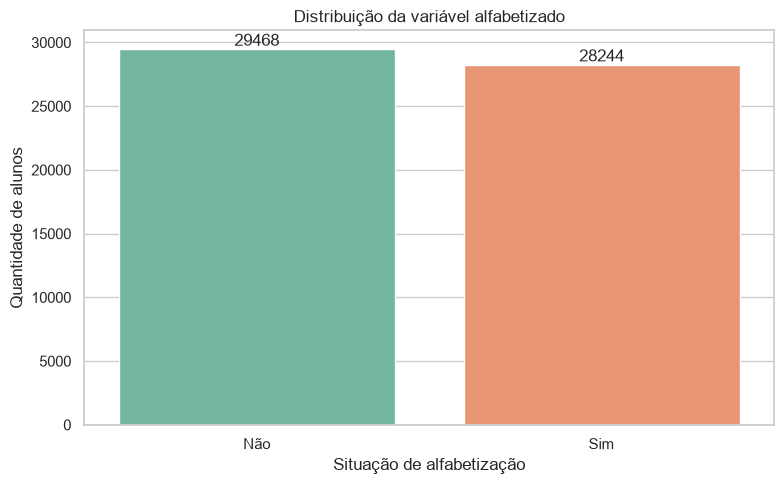

In [13]:
plt.figure(figsize=(8,5))

ax = sns.countplot(df_eda, x='alfabetizado', hue='alfabetizado', legend=False, palette='Set2')

plt.title("Distribuição da variável alfabetizado")
plt.xlabel("Situação de alfabetização")
plt.ylabel("Quantidade de alunos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 3.2 Evolução da alfabetização por ano

A análise temporal mostra uma pequena melhora na proporção de alunos classificados como alfabetizados entre 2023 e 2024.

Os resultados observados foram:

- **2023:** 48,23% alfabetizados
- **2024:** 49,62% alfabetizados

Isso representa um aumento de aproximadamente **1,39 ponto percentual** na taxa de alfabetização.

Apesar da melhora, a diferença entre os dois anos é relativamente pequena. Dessa forma, o ano de referência, isoladamente, não aparenta apresentar forte capacidade de separação entre alunos alfabetizados e não alfabetizados.

In [14]:
alfabetizacao_ano = pd.crosstab(
    df_eda['ano'], df_eda['alfabetizado'], normalize="index"
).mul(100).round(2)

alfabetizacao_ano

alfabetizado,Não,Sim
ano,,
2023,51.77,48.23
2024,50.38,49.62


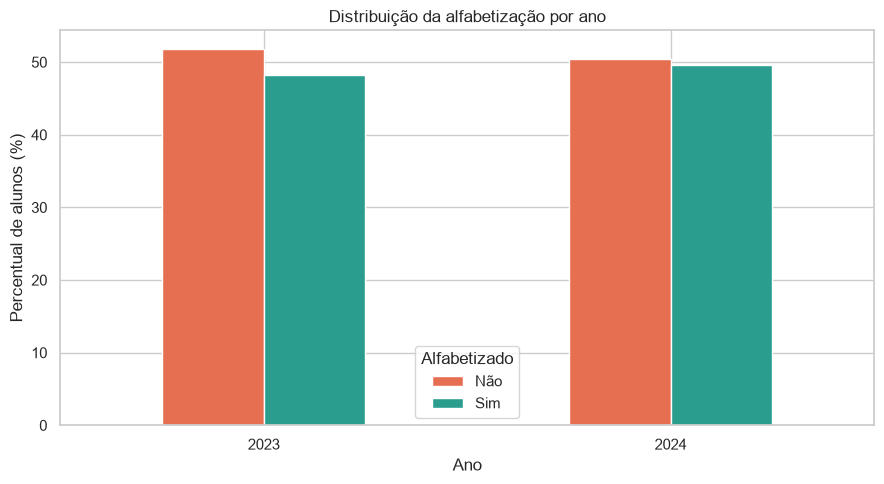

In [15]:
alfabetizacao_ano.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#e76f51", "#2a9d8f"]
)

plt.title("Distribuição da alfabetização por ano")
plt.xlabel("Ano")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.legend(title="Alfabetizado")

plt.tight_layout()
plt.show()

## 4. Análise das variáveis numéricas

Nesta etapa são analisadas as variáveis numéricas presentes no dataset com o objetivo de compreender seus padrões de distribuição, dispersão, assimetria e presença de valores extremos.

A análise exploratória dessas variáveis também auxilia na identificação de possíveis problemas de escala, concentração excessiva de valores, redundâncias e comportamentos que possam influenciar as etapas posteriores de pré-processamento e modelagem.

As variáveis `ano` e `caderno` não foram incluídas nesta análise numérica, pois, apesar de armazenadas como valores numéricos, possuem natureza essencialmente temporal e categórica, respectivamente.

In [16]:
var_numericas = (
    df_eda
    .select_dtypes(include="number")
    .columns
    .difference(
        ["ano", "caderno"]
    )
    .tolist()
)

var_numericas

['area_km2',
 'densidade_demografica',
 'media_alunos_docente_fund_ai',
 'media_alunos_turma_fund_ai',
 'media_prop_salas_climatizadas',
 'pib_per_capita',
 'populacao_2022',
 'prop_escolas_agua_potavel',
 'prop_escolas_banda_larga',
 'prop_escolas_biblioteca_leitura',
 'prop_escolas_esgoto_rede',
 'prop_escolas_internet',
 'prop_escolas_internet_aprendizagem',
 'prop_escolas_lab_informatica',
 'prop_escolas_rampas_acessibilidade',
 'prop_escolas_rurais',
 'qtd_escolas_censo',
 'renda_domiciliar_per_capita_mediana']

### 4.1 Visão geral das distribuições

Os histogramas mostram comportamentos distintos entre as variáveis numéricas.

Variáveis como `area_km2`, `densidade_demografica`, `pib_per_capita`, `populacao_2022` e `qtd_escolas_censo` apresentam forte assimetria à direita, refletindo a heterogeneidade entre os municípios.

Indicadores de infraestrutura, como acesso à água potável, internet e banda larga, concentram-se em valores elevados, enquanto variáveis como proporção de escolas rurais e laboratórios de informática apresentam maior concentração em valores baixos.

Já as médias de alunos por turma e por docente apresentam distribuições mais concentradas. A renda domiciliar per capita mediana também apresenta comportamento mais estável do que o PIB per capita.

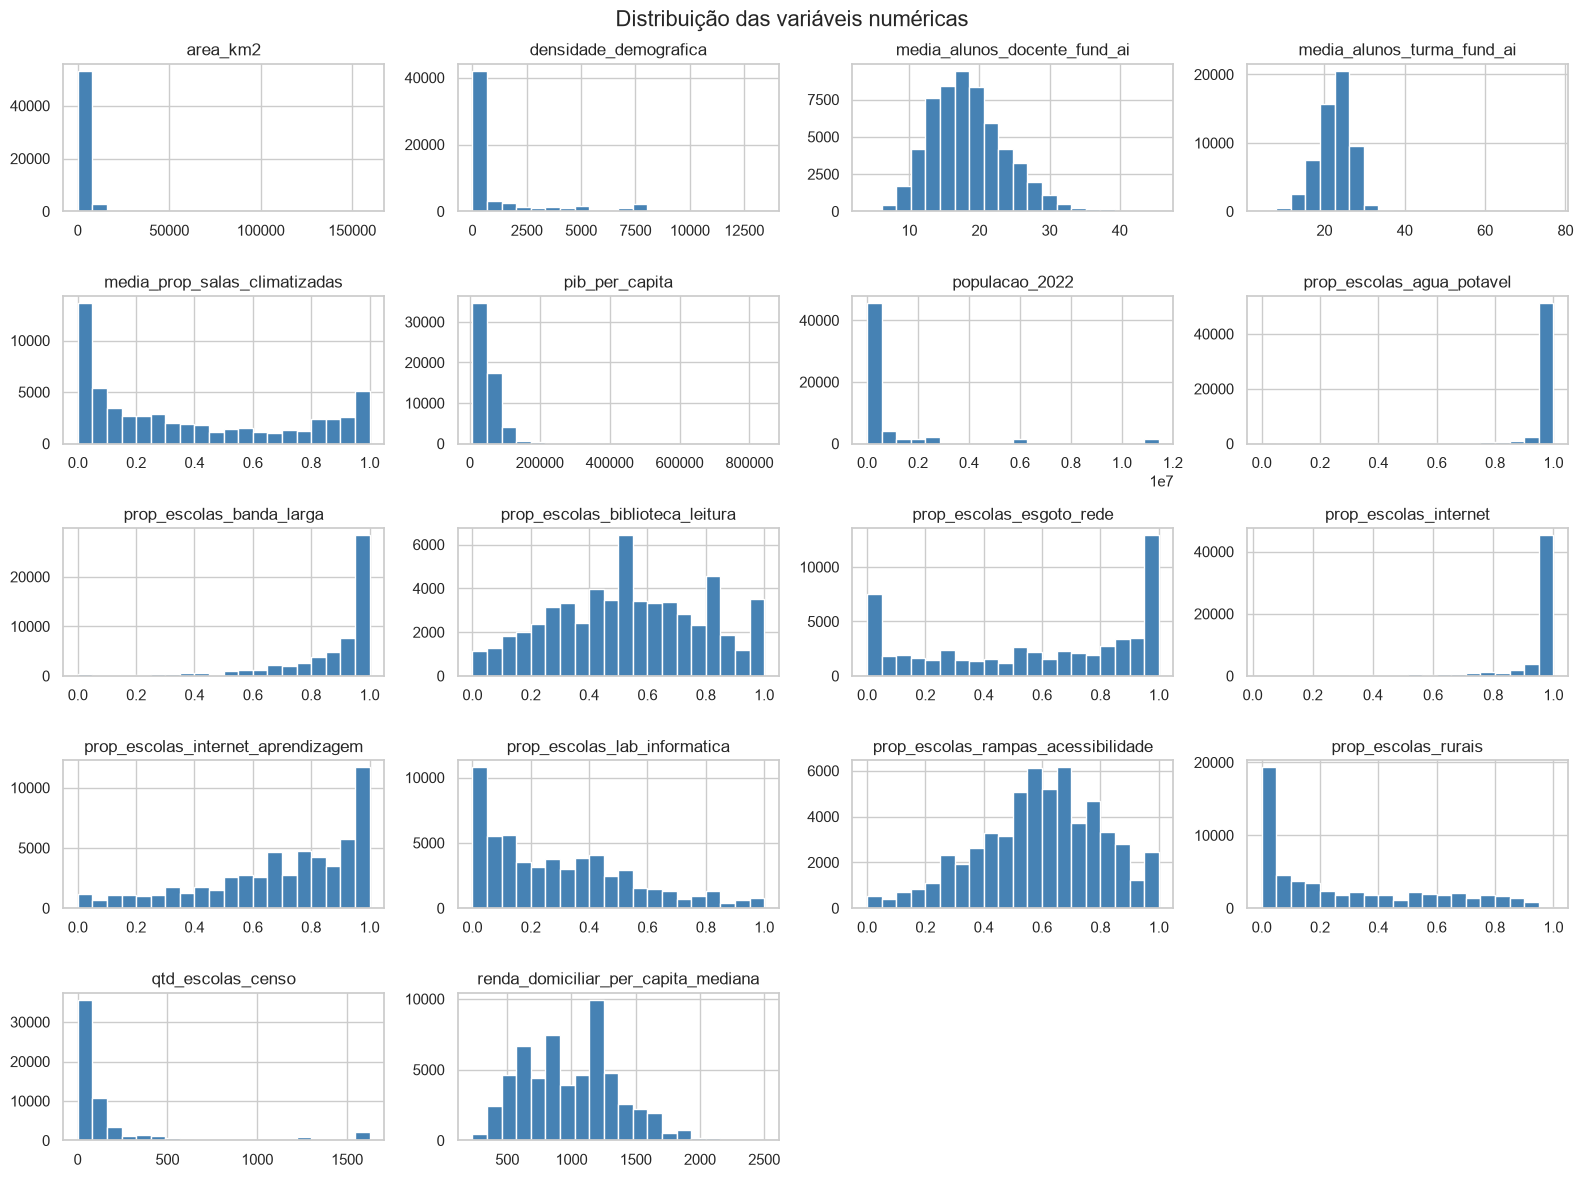

In [17]:
df_eda[var_numericas].hist(
    figsize=(16,12),
    bins=20,
    color="steelblue"
)
plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()
plt.show()

### 4.2 Comparação das variáveis numéricas por situação de alfabetização

As distribuições das variáveis numéricas apresentam forte sobreposição entre alunos alfabetizados e não alfabetizados.

Apesar de algumas diferenças sutis em indicadores de infraestrutura, conectividade, acessibilidade e renda, nenhuma variável isolada demonstra forte poder de separação entre as classes.

Esse resultado sugere que a alfabetização possui caráter multifatorial, dependendo da combinação de diferentes características socioeconômicas, territoriais e educacionais.

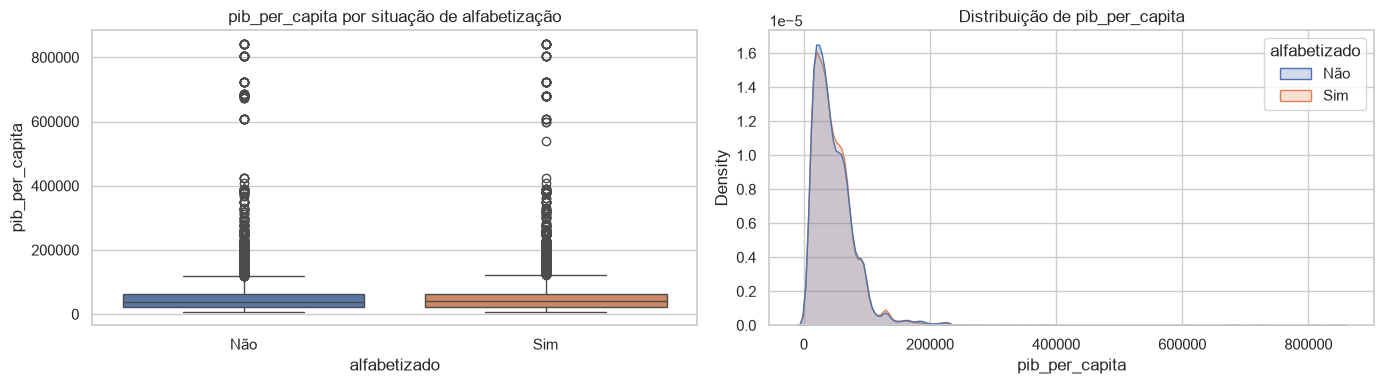

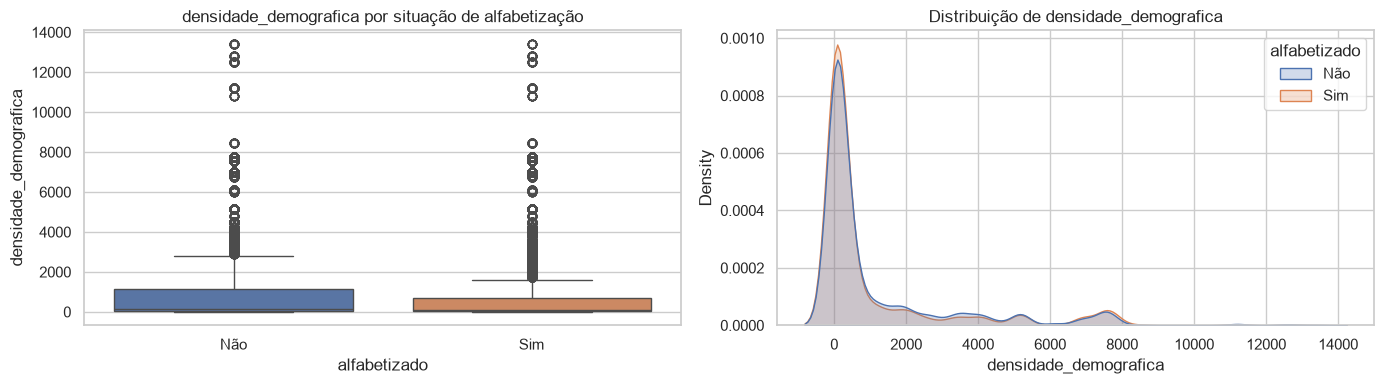

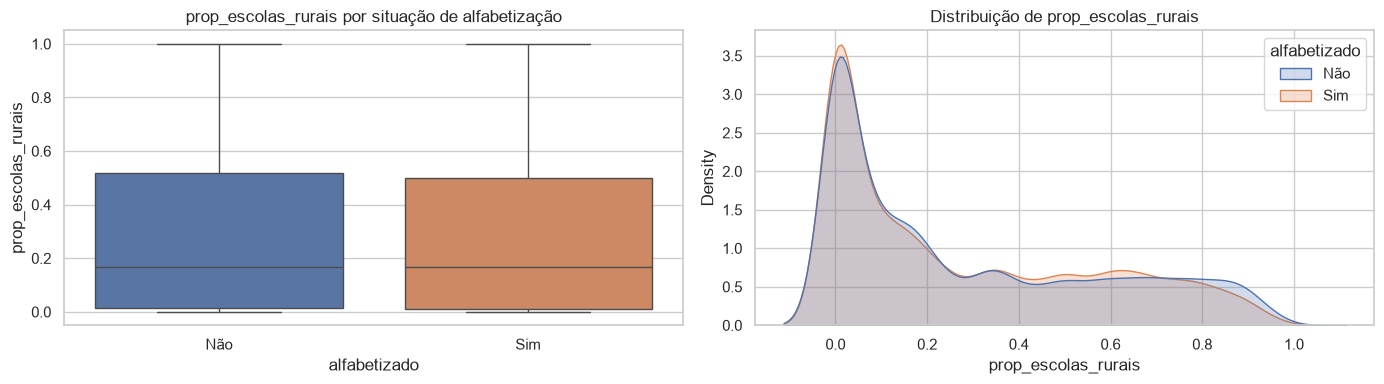

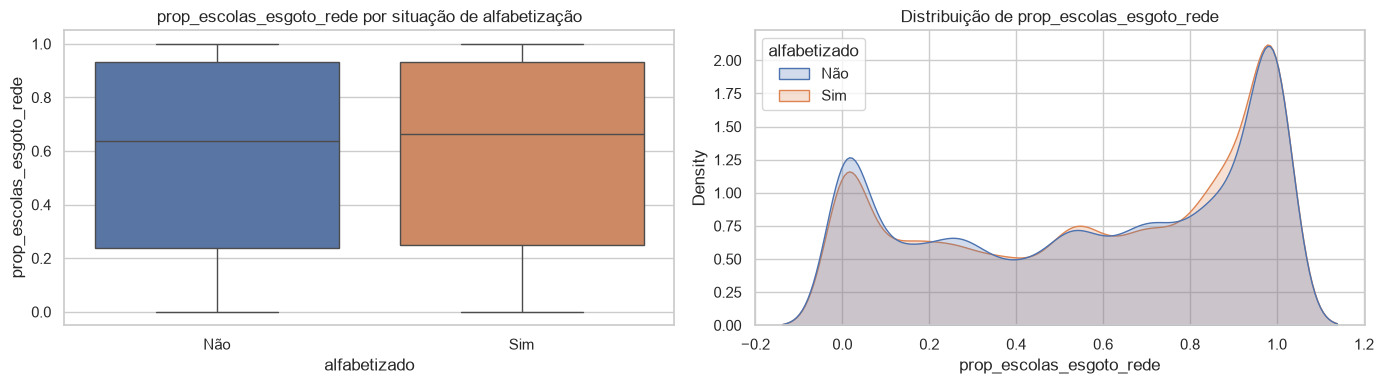

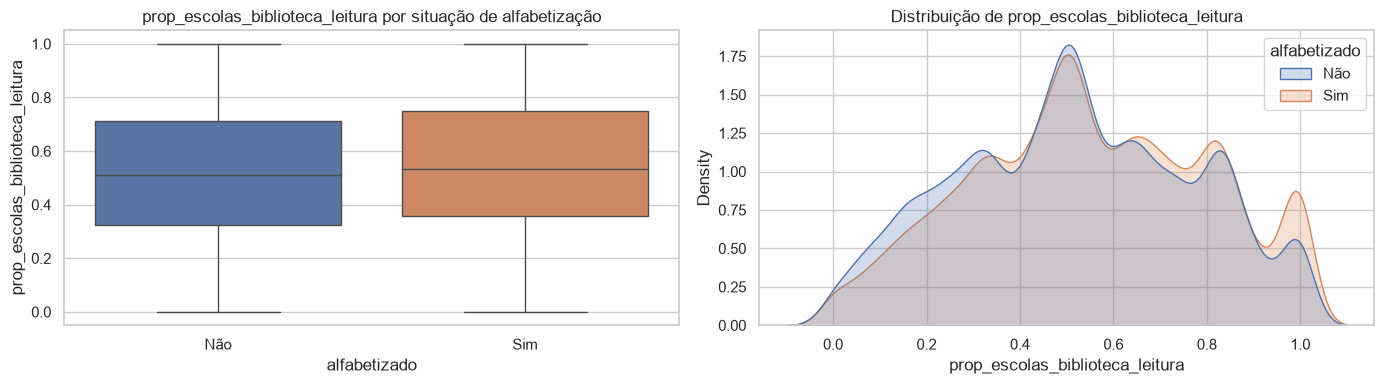

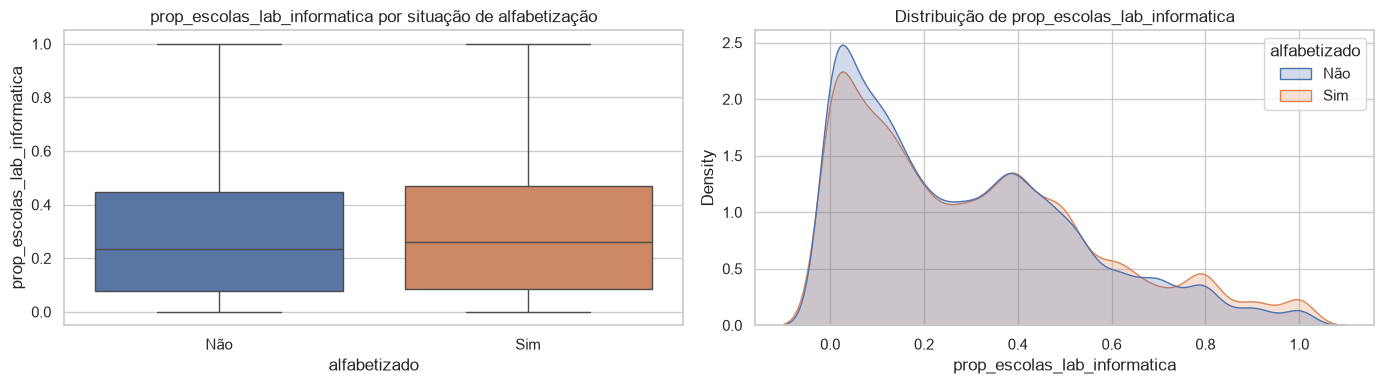

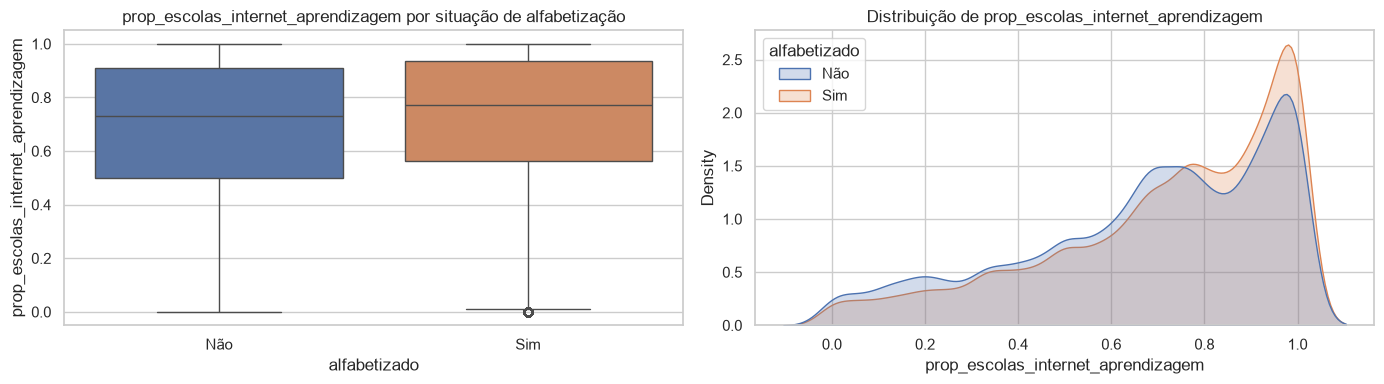

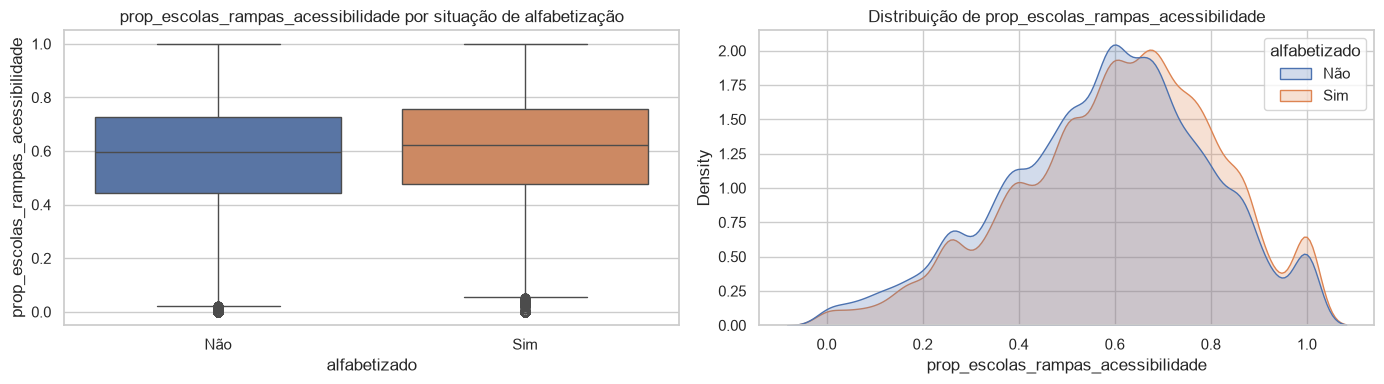

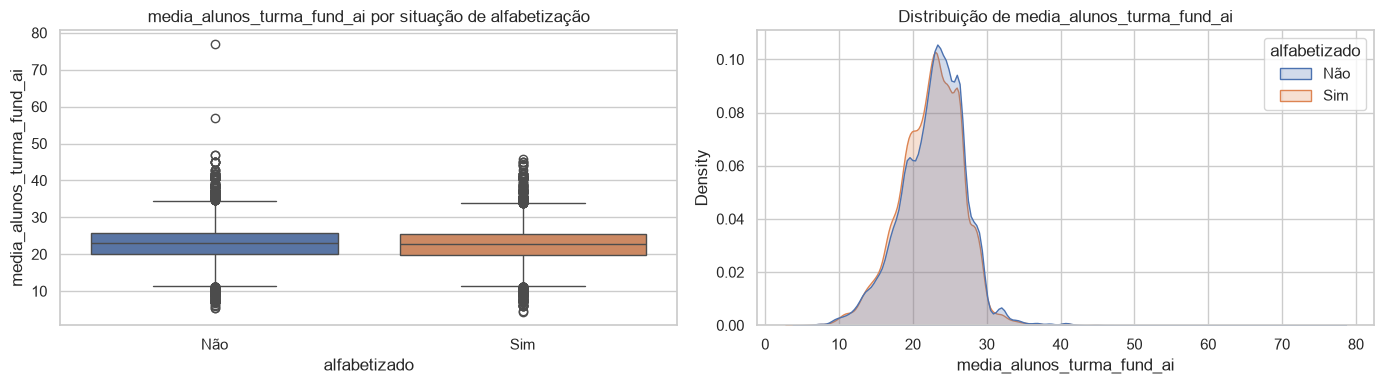

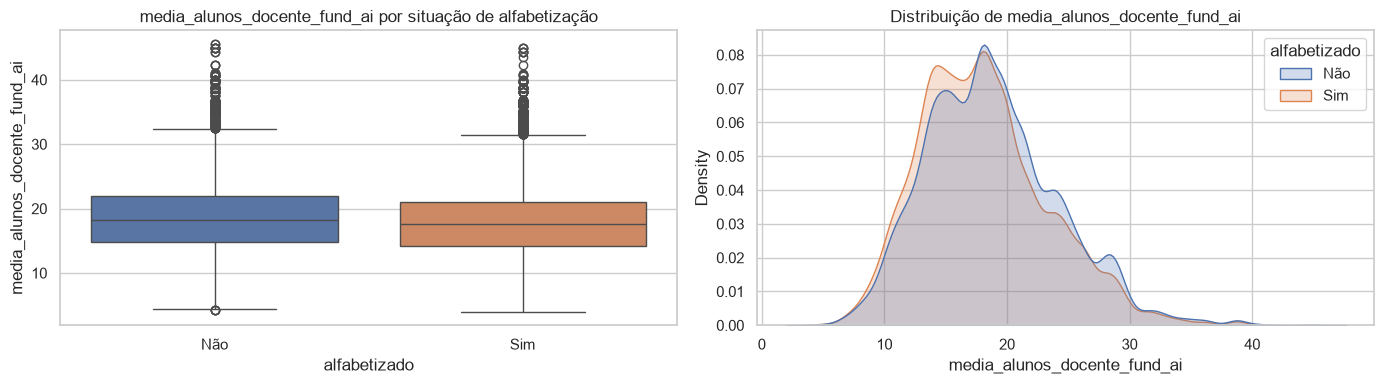

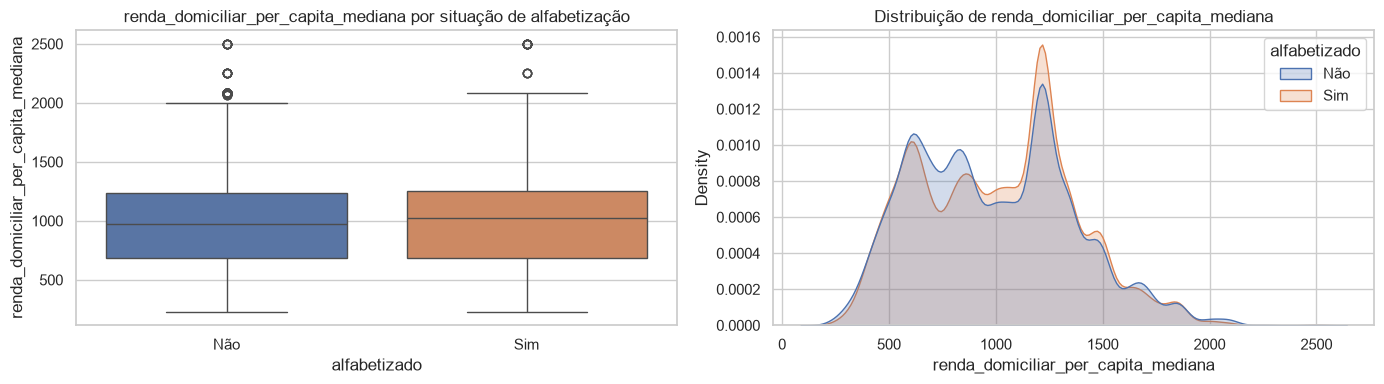

In [18]:
var_numericas_selecionadas = ["pib_per_capita", "densidade_demografica", "prop_escolas_rurais","prop_escolas_esgoto_rede", 
                              "prop_escolas_biblioteca_leitura","prop_escolas_lab_informatica","prop_escolas_internet_aprendizagem",
                              "prop_escolas_rampas_acessibilidade","media_alunos_turma_fund_ai","media_alunos_docente_fund_ai", "renda_domiciliar_per_capita_mediana"]

for coluna in var_numericas_selecionadas:

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(data=df_eda, x="alfabetizado", y=coluna, hue="alfabetizado", legend=False, ax=ax[0])
    ax[0].set_title(f"{coluna} por situação de alfabetização")

    sns.kdeplot(data=df_eda, x=coluna, hue="alfabetizado", fill=True, common_norm=False, ax=ax[1])
    ax[1].set_title(f"Distribuição de {coluna}")

    plt.tight_layout()
    plt.show()

### 4.3 Correlação entre variáveis numéricas

As correlações entre as variáveis numéricas foram avaliadas pelo coeficiente de Spearman, adequado para distribuições assimétricas e relações monotônicas não necessariamente lineares.

A matriz evidencia alguns grupos de variáveis relacionadas entre si, especialmente indicadores de porte municipal, infraestrutura escolar e conectividade.

Também são observadas associações entre as variáveis de tamanho de turma e número médio de alunos por docente.

Em relação ao alvo `alfabetizado_bin`, as correlações individuais permanecem baixas, reforçando que a alfabetização não é explicada por uma única variável numérica isolada, mas pela combinação de diferentes fatores.

In [19]:
df_eda["alfabetizado_bin"] = (
    df_eda["alfabetizado"]
    .map({
        "Não": 0,
        "Sim": 1
    })
)

In [20]:
var_correlacao = ["pib_per_capita", "populacao_2022", "area_km2", "densidade_demografica", "qtd_escolas_censo",
                  "prop_escolas_rurais", "prop_escolas_agua_potavel", "prop_escolas_esgoto_rede", "prop_escolas_biblioteca_leitura",
                  "prop_escolas_lab_informatica", "prop_escolas_internet", "prop_escolas_internet_aprendizagem",
                  "prop_escolas_banda_larga", "prop_escolas_rampas_acessibilidade", "media_alunos_turma_fund_ai",
                  "media_alunos_docente_fund_ai", "media_prop_salas_climatizadas", "renda_domiciliar_per_capita_mediana", "alfabetizado_bin"]

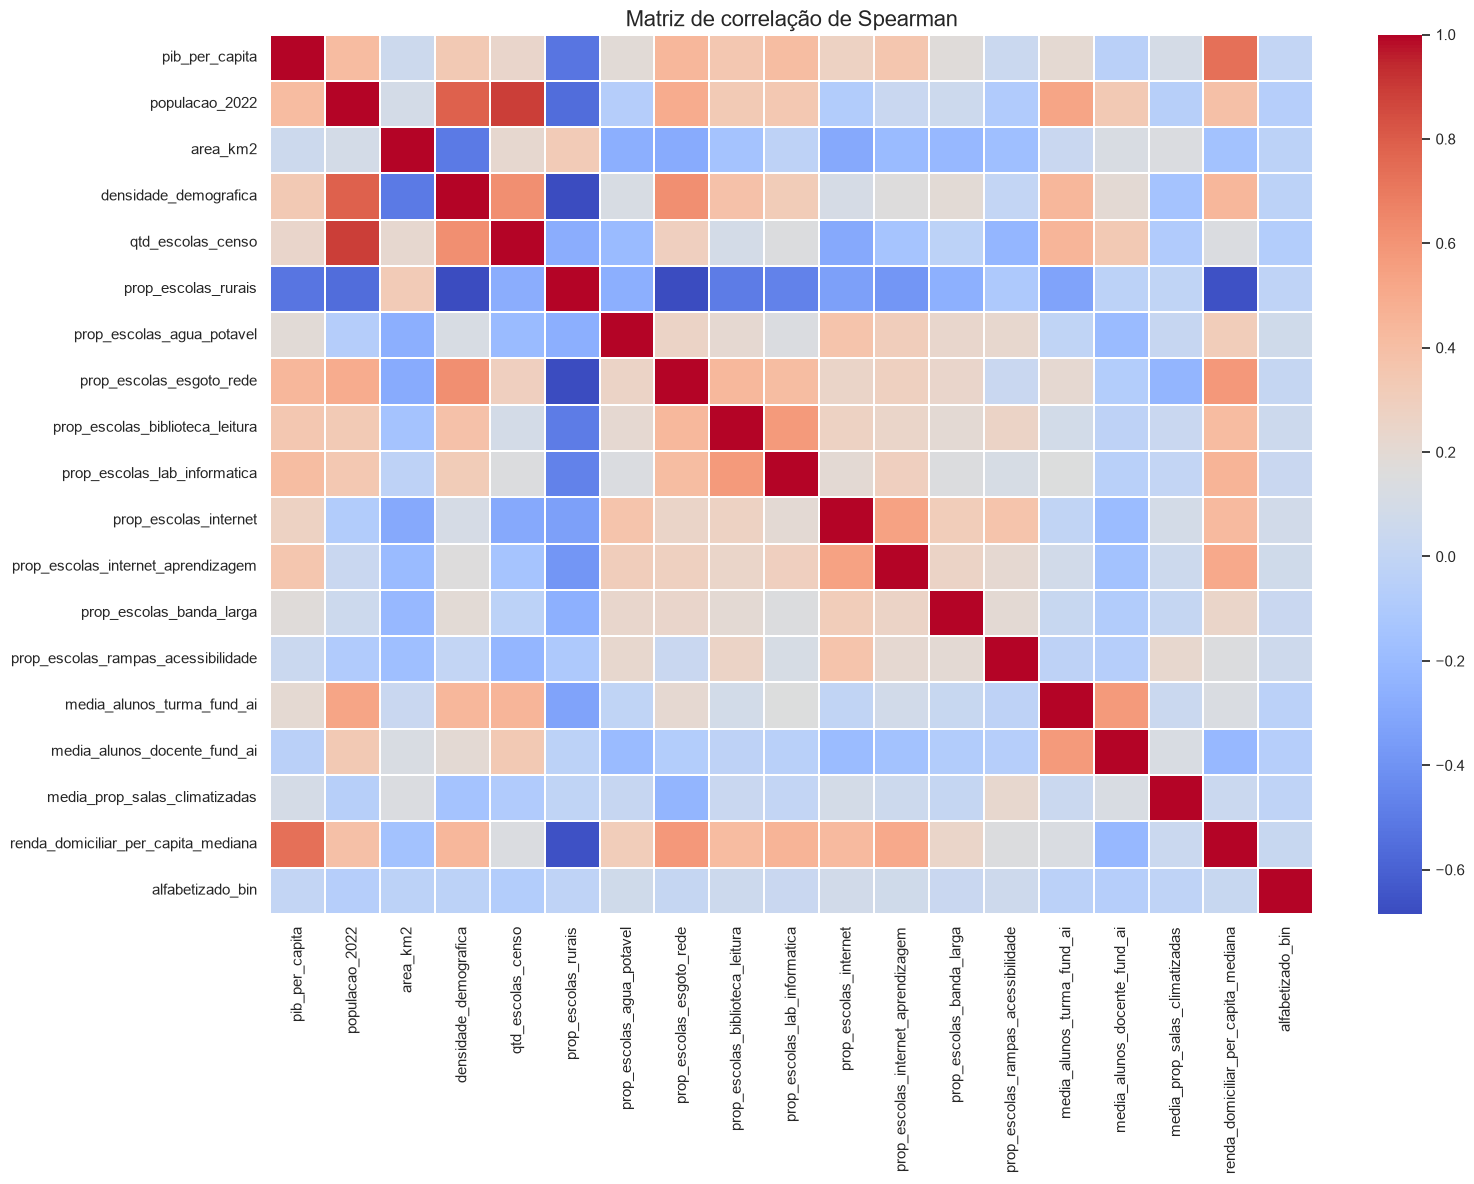

In [21]:
matriz_corr = (df_eda[var_correlacao].corr(method="spearman"))

plt.figure(figsize=(16, 12))

sns.heatmap(matriz_corr, cmap="coolwarm", linewidths=0.3)

plt.title("Matriz de correlação de Spearman", fontsize=16)

plt.tight_layout()
plt.show()

### 4.4 Associação das variáveis numéricas com a alfabetização

A associação entre as variáveis numéricas e a variável alvo foi avaliada por meio da correlação de Spearman com `alfabetizado_bin`.

De forma geral, as correlações apresentaram baixa magnitude, variando aproximadamente entre **-0,08 e 0,08**.

As maiores associações positivas apareceram em indicadores de infraestrutura escolar, como acesso à internet, internet para aprendizagem, água potável, rampas de acessibilidade e biblioteca.

Já associações negativas foram observadas em variáveis como quantidade de escolas, população, média de alunos por docente e média de alunos por turma.

Apesar dessas diferenças, nenhuma variável numérica apresentou associação forte com a alfabetização de forma isolada.

In [22]:
corr_target = (matriz_corr["alfabetizado_bin"].drop("alfabetizado_bin").sort_values(key=abs, ascending=False))

corr_target

prop_escolas_internet                  0.083264
qtd_escolas_censo                     -0.076717
prop_escolas_internet_aprendizagem     0.076397
prop_escolas_agua_potavel              0.075505
media_alunos_docente_fund_ai          -0.065528
prop_escolas_rampas_acessibilidade     0.063183
populacao_2022                        -0.061807
prop_escolas_biblioteca_leitura        0.057285
media_alunos_turma_fund_ai            -0.038508
prop_escolas_banda_larga               0.034286
prop_escolas_lab_informatica           0.034156
densidade_demografica                 -0.032659
renda_domiciliar_per_capita_mediana    0.029164
area_km2                              -0.027187
prop_escolas_esgoto_rede               0.016340
media_prop_salas_climatizadas         -0.016143
prop_escolas_rurais                   -0.015722
pib_per_capita                         0.003653
Name: alfabetizado_bin, dtype: float64

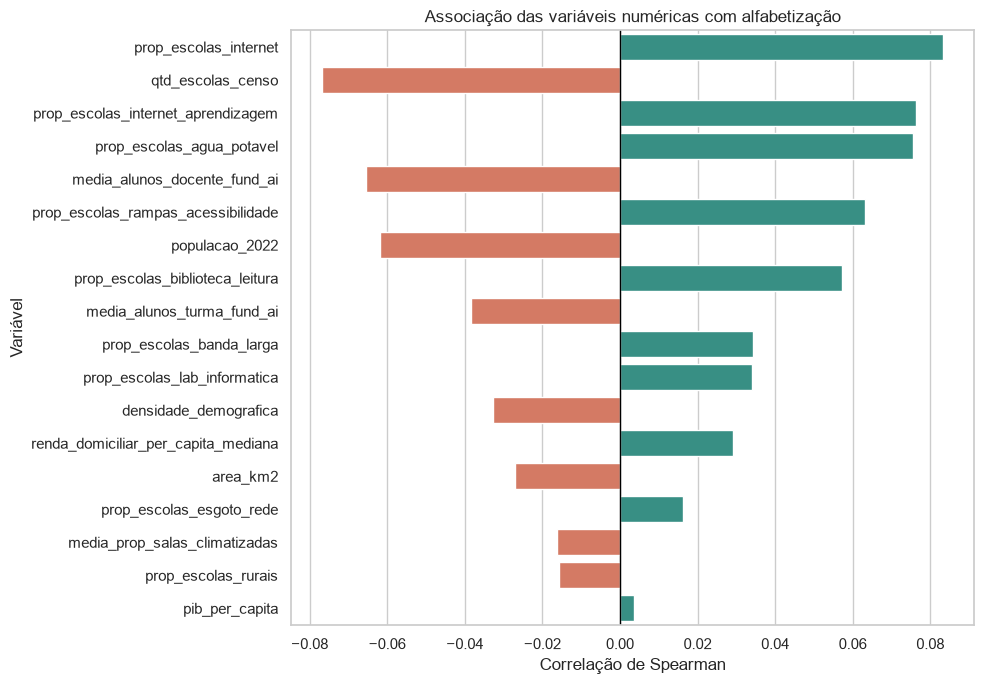

In [23]:
plt.figure(figsize=(10, 7))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in corr_target.values]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=cores, legend=False)

plt.axvline(0, color="black", linewidth=1)

plt.title("Associação das variáveis numéricas com alfabetização")

plt.xlabel("Correlação de Spearman")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

### 4.5 Síntese da análise das variáveis numéricas

A análise numérica evidenciou forte heterogeneidade entre os municípios e diferenças relevantes em aspectos territoriais, socioeconômicos e educacionais.

Entretanto, as distribuições entre alunos alfabetizados e não alfabetizados apresentam elevada sobreposição, e as correlações individuais com a variável alvo são baixas.

Esses resultados reforçam que a alfabetização possui caráter multifatorial, sendo mais adequadamente analisada pela combinação de diferentes variáveis do que por fatores isolados.

As evidências desta etapa serão utilizadas como apoio para o pré-processamento e a modelagem supervisionada.

## 5. Análise das variáveis categóricas

Nesta seção são analisadas as variáveis categóricas com o objetivo de identificar diferenças na taxa de alfabetização entre grupos e possíveis padrões territoriais e educacionais.

Também será avaliada a força de associação entre essas variáveis e a variável alvo `alfabetizado`.

Variáveis utilizadas apenas como identificadores não foram consideradas nesta análise.

In [24]:
var_categoricas = ["ano", "caderno", "rede", "presenca", "preenchimento_caderno", "sigla_uf", "regiao"]

var_categoricas

['ano',
 'caderno',
 'rede',
 'presenca',
 'preenchimento_caderno',
 'sigla_uf',
 'regiao']

### 5.1 Visão geral das variáveis categóricas

A maior parte das variáveis categóricas possui baixa cardinalidade, facilitando a interpretação dos padrões.

As variáveis `ano`, `rede`, `presenca` e `preenchimento_caderno` possuem duas categorias, enquanto `caderno` possui quatro e `regiao` possui cinco.

A variável `sigla_uf` apresenta maior cardinalidade, com 26 Unidades Federativas representadas.

Também se observa concentração da amostra em algumas categorias, especialmente na rede municipal, que representa a maior parte dos registros.

In [25]:
resumo_categoricas = []

for coluna in var_categoricas:
    resumo_categoricas.append({
        "variavel": coluna,
        "categorias": df_eda[coluna].nunique(),
        "categoria_mais_frequente": df_eda[coluna].mode().iloc[0],
        "frequencia_maior_categoria": df_eda[coluna].value_counts().iloc[0]
    })

resumo_categoricas = pd.DataFrame(resumo_categoricas)

resumo_categoricas

,variavel,categorias,categoria_mais_frequente,frequencia_maior_categoria
0,ano,2,2024,29431
1,caderno,4,1,22814
2,rede,2,Municipal,51402
3,presenca,2,Presente,48050
4,preenchimento_caderno,2,Prova preenchida,48021
5,sigla_uf,26,MG,6168
6,regiao,5,Sudeste,18050


In [26]:
def resumo_categorica(df, coluna):
    resumo = (
        df.groupby(
            coluna,
            dropna=False
        )["alfabetizado_bin"]
        .agg(
            quantidade="size",
            taxa_alfabetizacao="mean"
        )
        .reset_index()
    )

    resumo["percentual_amostra"] = (
        resumo["quantidade"]
        / len(df)
        * 100
    )

    resumo["taxa_alfabetizacao"] *= 100

    return resumo.sort_values(
        "taxa_alfabetizacao",
        ascending=False
    )

### 5.2 Taxa de alfabetização por categorias

As taxas de alfabetização foram comparadas entre as principais variáveis categóricas.

Observa-se pouca variação entre os anos de 2023 e 2024 e diferença moderada entre as redes estadual e municipal.

As maiores diferenças aparecem nas variáveis `presenca` e `preenchimento_caderno`, nas quais alunos ausentes ou com prova não preenchida apresentam taxa de alfabetização igual a 0%. Esse comportamento indica forte relação dessas variáveis com o próprio processo de avaliação e deve ser considerado com cautela na modelagem.

A variável `caderno` também apresentou comportamento atípico, especialmente na categoria 12, com taxa de alfabetização muito inferior às demais.

Regionalmente, Sudeste, Centro-Oeste e Sul apresentam taxas próximas, enquanto a região Norte apresenta percentual consideravelmente menor.

,ano,quantidade,taxa_alfabetizacao,percentual_amostra
1,2024,29431,49.62,51.0
0,2023,28281,48.23,49.0


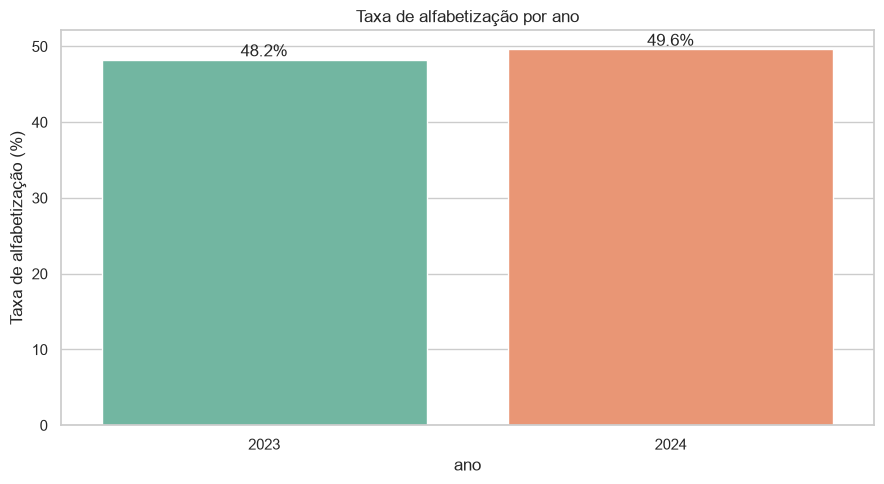

,caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,10,16227,51.61,28.12
2,11,16134,51.26,27.96
0,1,22814,49.42,39.53
3,12,2537,12.81,4.40


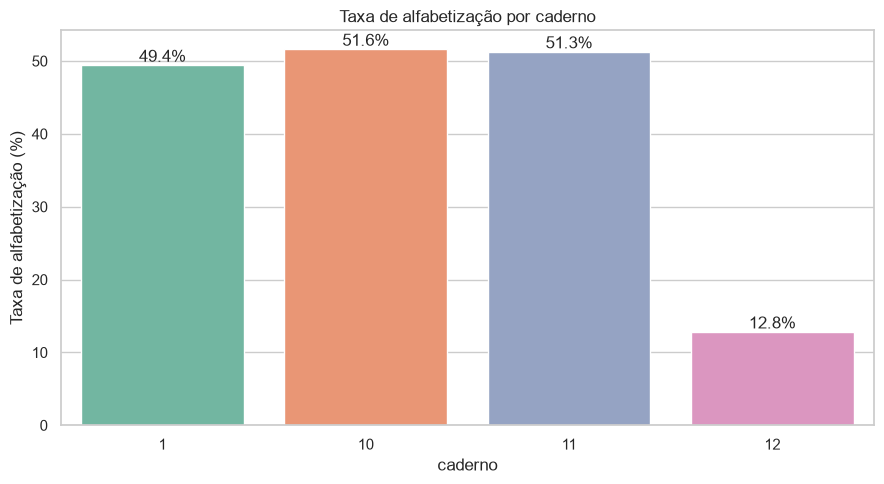

,rede,quantidade,taxa_alfabetizacao,percentual_amostra
0,Estadual,6310,51.52,10.93
1,Municipal,51402,48.62,89.07


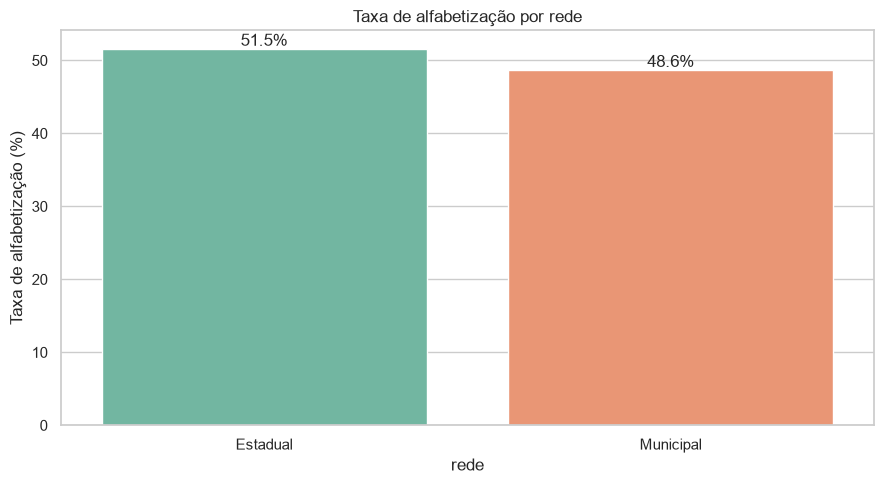

,presenca,quantidade,taxa_alfabetizacao,percentual_amostra
1,Presente,48050,58.78,83.26
0,Ausente,9662,0.00,16.74


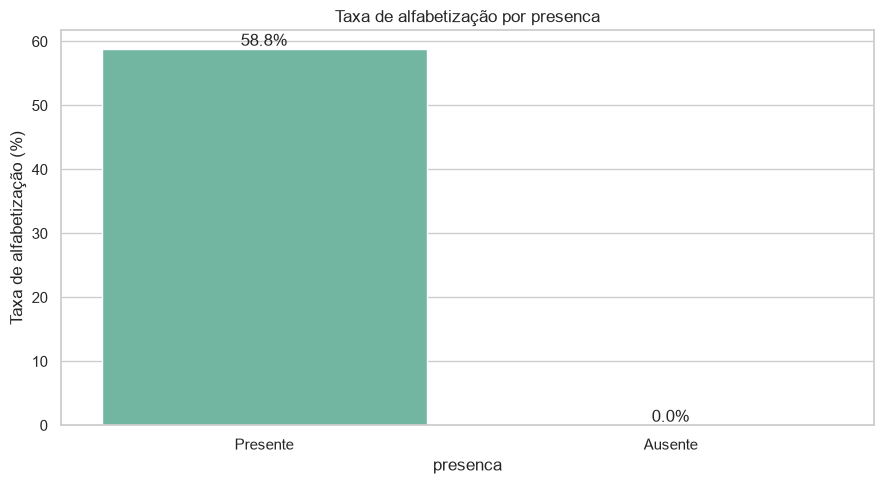

,preenchimento_caderno,quantidade,taxa_alfabetizacao,percentual_amostra
1,Prova preenchida,48021,58.82,83.21
0,Prova não preenchida,9691,0.00,16.79


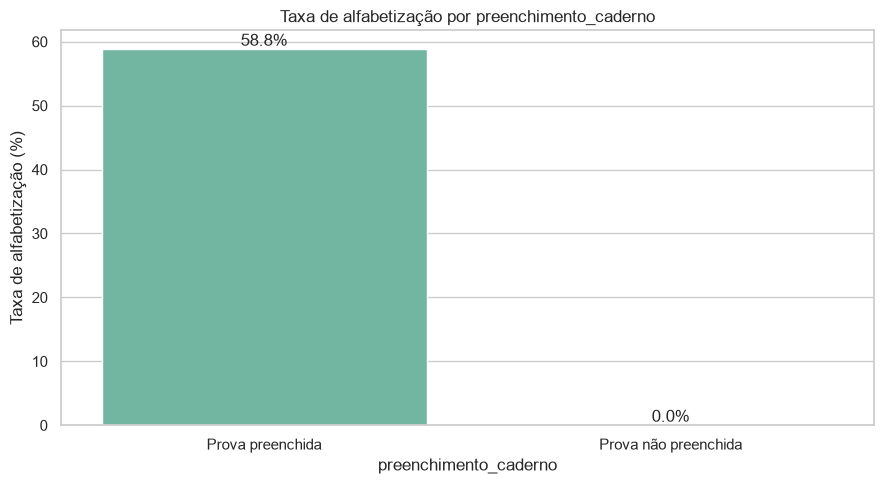

,regiao,quantidade,taxa_alfabetizacao,percentual_amostra
3,Sudeste,18050,51.22,31.28
0,Centro-Oeste,5836,51.15,10.11
4,Sul,10927,50.40,18.93
1,Nordeste,16206,48.93,28.08
2,Norte,6693,38.50,11.60


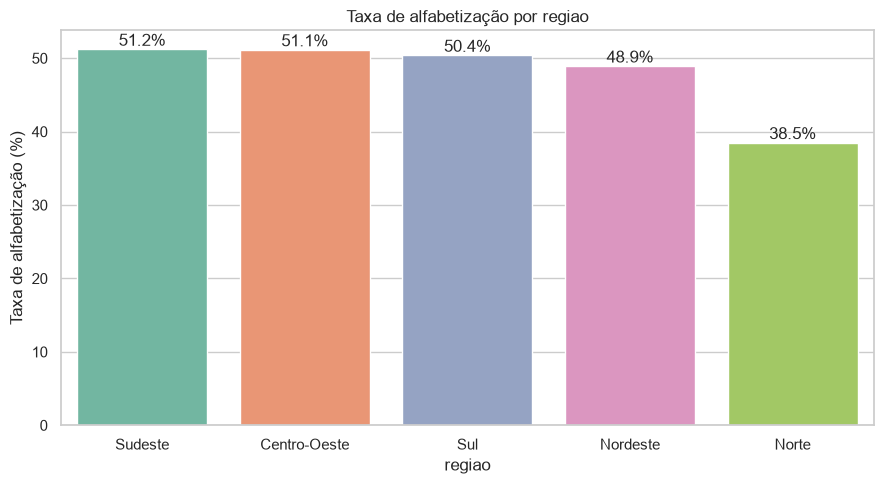

In [27]:
var_categoricas_principais = ["ano", "caderno", "rede", "presenca", "preenchimento_caderno", "regiao"]

for coluna in var_categoricas_principais:

    resumo = resumo_categorica(
        df_eda,
        coluna
    )

    display(resumo.round(2))

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=resumo,
        x=coluna,
        y="taxa_alfabetizacao",
        hue=coluna,
        legend=False,
        palette="Set2"
    )

    plt.title(
        f"Taxa de alfabetização por {coluna}"
    )

    plt.xlabel(coluna)
    plt.ylabel("Taxa de alfabetização (%)")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%"
        )

    plt.tight_layout()
    plt.show()

### 5.3 Análise por Unidade Federativa

A análise por Unidade Federativa evidencia diferenças territoriais relevantes nas taxas de alfabetização.

O Ceará apresenta a maior taxa observada na amostra, com aproximadamente **81%**, enquanto outros estados apresentam percentuais consideravelmente menores.

Também são observadas diferenças importantes entre as UFs, reforçando que o contexto territorial pode contribuir para padrões distintos de alfabetização.

Esses resultados devem ser interpretados em conjunto com o tamanho da amostra disponível em cada estado, evitando atribuir as diferenças exclusivamente ao fator geográfico.

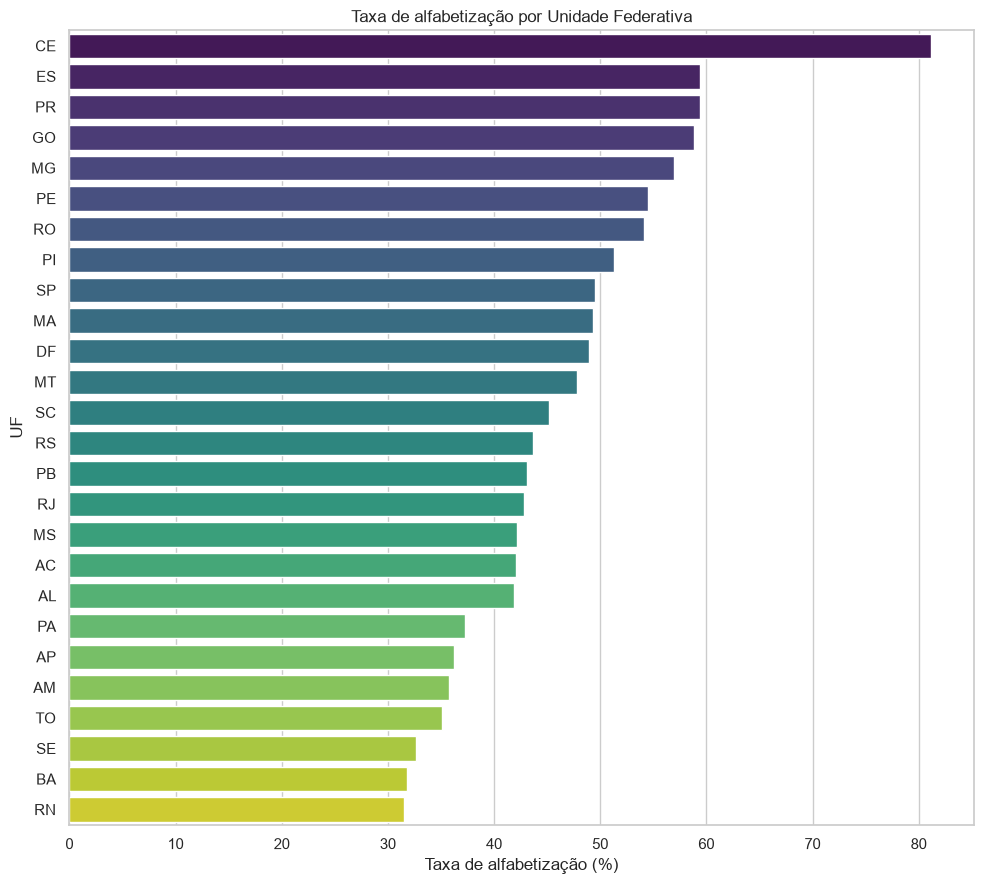

In [28]:
resumo_uf = resumo_categorica(
    df_eda,
    "sigla_uf"
)

plt.figure(figsize=(10, 9))

sns.barplot(
    data=resumo_uf,
    x="taxa_alfabetizacao",
    y="sigla_uf",
    hue="sigla_uf",
    legend=False,
    palette="viridis"
)

plt.title(
    "Taxa de alfabetização por Unidade Federativa"
)

plt.xlabel("Taxa de alfabetização (%)")
plt.ylabel("UF")

plt.tight_layout()
plt.show()

In [29]:
resumo_uf[
    [
        "sigla_uf",
        "quantidade",
        "percentual_amostra",
        "taxa_alfabetizacao"
    ]
].round(2)

,sigla_uf,quantidade,percentual_amostra,taxa_alfabetizacao
5,CE,2860,4.96,81.15
7,ES,1461,2.53,59.41
17,PR,4392,7.61,59.36
8,GO,2458,4.26,58.83
10,MG,6168,10.69,56.96
15,PE,2391,4.14,54.54
20,RO,710,1.23,54.08
16,PI,1022,1.77,51.27
24,SP,6003,10.40,49.53
9,MA,2237,3.88,49.31


### 5.4 Força de associação com a variável alvo

A associação entre as variáveis categóricas e `alfabetizado` foi avaliada por meio do coeficiente de Cramér's V.

As maiores associações foram observadas em `preenchimento_caderno` e `presenca`, ambas próximas de **0,44**, indicando relação substancial com a variável alvo.

A variável `sigla_uf` apresentou associação moderada, enquanto `caderno` apresentou associação inferior, porém ainda relevante. Já `regiao`, `rede` e `ano` apresentaram associações de baixa magnitude.

Embora os testes de qui-quadrado apresentem significância estatística, a interpretação deve priorizar a magnitude da associação, especialmente devido ao tamanho da amostra.

In [30]:
from scipy.stats import chi2_contingency

In [31]:
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabela)[0]

    n = tabela.values.sum()

    r, k = tabela.shape

    denominador = min(k - 1, r - 1)

    if denominador == 0:
        return np.nan

    return np.sqrt(
        (chi2 / n) / denominador
    )

In [32]:
associacoes_categoricas = []

for coluna in var_categoricas:

    tabela = pd.crosstab(
        df_eda[coluna],
        df_eda["alfabetizado"]
    )

    chi2, p_value, _, _ = chi2_contingency(
        tabela
    )

    v_cramer = cramers_v(
        df_eda[coluna],
        df_eda["alfabetizado"]
    )

    associacoes_categoricas.append({
        "variavel": coluna,
        "cramers_v": v_cramer,
        "p_value": p_value
    })

associacoes_categoricas = (
    pd.DataFrame(associacoes_categoricas)
    .sort_values(
        "cramers_v",
        ascending=False
    )
)

associacoes_categoricas

,variavel,cramers_v,p_value
4,preenchimento_caderno,0.439755,0.000000e+00
3,presenca,0.438964,0.000000e+00
5,sigla_uf,0.225710,0.000000e+00
1,caderno,0.156217,4.466371e-305
6,regiao,0.077871,1.788511e-74
2,rede,0.018040,1.464929e-05
0,ano,0.013875,8.587406e-04


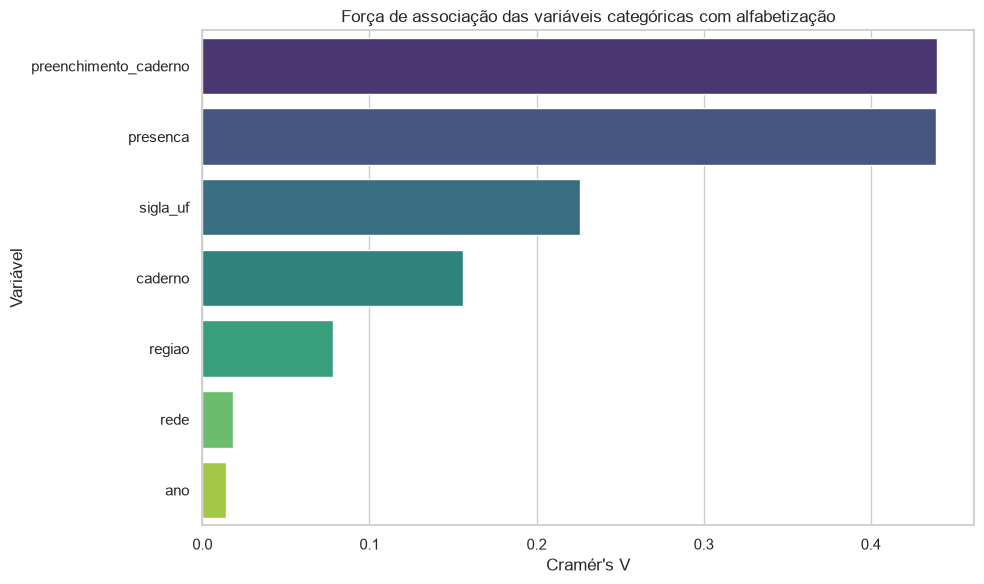

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=associacoes_categoricas,
    x="cramers_v",
    y="variavel",
    hue="variavel",
    legend=False,
    palette="viridis"
)

plt.title(
    "Força de associação das variáveis categóricas com alfabetização"
)

plt.xlabel("Cramér's V")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

### 5.5 Avaliação de possíveis variáveis com data leakage

As variáveis `presenca` e `preenchimento_caderno` apresentaram forte associação com `alfabetizado`, além de taxa de alfabetização igual a 0% entre alunos ausentes ou com prova não preenchida.

Esse comportamento indica que essas variáveis podem refletir o próprio processo de aplicação e registro da avaliação, e não apenas características disponíveis previamente para previsão.

Por esse motivo, ambas foram tratadas como potenciais fontes de **data leakage** e excluídas do conjunto de preditores utilizado na modelagem.

### 5.6 Síntese da análise das variáveis categóricas

As variáveis categóricas apresentaram associações mais evidentes com a alfabetização do que as variáveis numéricas analisadas isoladamente.

Destacam-se as diferenças entre Unidades Federativas, o comportamento atípico do `caderno 12` e a forte associação de `presenca` e `preenchimento_caderno`, consideradas potenciais fontes de data leakage.

Os resultados reforçam a relevância de características territoriais e a necessidade de cautela com variáveis diretamente relacionadas ao processo de avaliação.

## 6. Investigações complementares

### 6.1 Investigação do comportamento do caderno 12

O `caderno 12` apresentou taxa de alfabetização significativamente inferior às demais categorias, com aproximadamente **12,8%**, enquanto os cadernos 1, 10 e 11 ficaram próximos de 50%.

Para investigar esse comportamento, foram analisadas as variáveis `presenca` e `preenchimento_caderno`.

No caderno 12, cerca de **79,6% dos alunos estavam ausentes** e aproximadamente **79,8% não possuíam a prova preenchida**, comportamento muito diferente dos demais cadernos.

Como alunos ausentes ou com prova não preenchida apresentam taxa de alfabetização igual a 0%, a baixa taxa observada no caderno 12 está fortemente associada ao processo de aplicação da avaliação.

Dessa forma, o resultado não deve ser interpretado como evidência de maior dificuldade do conteúdo do caderno 12.

In [34]:
caderno_presenca = pd.crosstab(
    df_eda["caderno"],
    df_eda["presenca"],
    normalize="index"
).mul(100).round(2)

caderno_presenca

presenca,Ausente,Presente
caderno,,
1,15.60,84.40
10,12.71,87.29
11,12.53,87.47
12,79.58,20.42


In [35]:
caderno_preenchimento = pd.crosstab(
    df_eda["caderno"],
    df_eda["preenchimento_caderno"],
    normalize="index"
).mul(100).round(2)

caderno_preenchimento

preenchimento_caderno,Prova não preenchida,Prova preenchida
caderno,,
1,15.66,84.34
10,12.74,87.26
11,12.56,87.44
12,79.78,20.22


#### Distribuição temporal

O `caderno 12` aparece nos dois anos analisados, com maior concentração em **2023 (59,24%)** do que em **2024 (40,76%)**.

Essa diferença temporal, porém, não é suficiente para explicar isoladamente a baixa taxa de alfabetização observada nessa categoria.

Assim, o comportamento atípico do caderno 12 permanece mais associado às altas proporções de ausência e não preenchimento da avaliação.

In [36]:
caderno_ano = pd.crosstab(
    df_eda["caderno"],
    df_eda["ano"],
    normalize="index"
).mul(100).round(2)

caderno_ano

ano,2023,2024
caderno,,
1,52.81,47.19
10,45.10,54.90
11,45.94,54.06
12,59.24,40.76


#### Distribuição por rede de ensino

A distribuição do `caderno 12` entre as redes estadual e municipal é muito semelhante à observada nos demais cadernos.

Cerca de **89% dos registros pertencem à rede municipal** e **11% à rede estadual**.

Assim, não há evidências de que a rede de ensino explique o comportamento atípico do caderno 12.

In [37]:
caderno_rede = pd.crosstab(
    df_eda["caderno"],
    df_eda["rede"],
    normalize="index"
).mul(100).round(2)

caderno_rede

rede,Estadual,Municipal
caderno,,
1,10.74,89.26
10,10.98,89.02
11,11.14,88.86
12,11.04,88.96


#### Distribuição regional

O `caderno 12` apresenta distribuição entre todas as regiões brasileiras, sem concentração regional suficiente para explicar isoladamente sua baixa taxa de alfabetização.

Apesar de pequenas diferenças de participação entre as regiões, o comportamento atípico permanece mais associado às variáveis `presenca` e `preenchimento_caderno` do que à localização regional.

In [38]:
caderno_regiao = pd.crosstab(
    df_eda["caderno"],
    df_eda["regiao"],
    normalize="index"
).mul(100).round(2)

caderno_regiao

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
caderno,,,,,
1,10.19,28.58,10.80,31.04,19.39
10,10.11,27.98,12.04,31.76,18.11
11,10.01,28.51,11.80,31.28,18.41
12,10.05,21.48,14.66,30.35,23.45


### 6.2 Conclusão da investigação do caderno 12

O comportamento atípico do `caderno 12` está fortemente associado à elevada ausência dos alunos e ao não preenchimento da avaliação.

Cerca de **80% dos registros** dessa categoria correspondem a alunos ausentes ou com prova não preenchida, percentual muito superior ao observado nos demais cadernos.

Assim, a baixa taxa de alfabetização do caderno 12 parece refletir principalmente características operacionais do processo de avaliação.

Por esse motivo, a variável `caderno` foi tratada com cautela e excluída do conjunto de preditores utilizado na modelagem.

## 6.3 Municípios com maiores e menores taxas de alfabetização

### 6.3.1 Construção do resumo municipal

Para avaliar diferenças territoriais em nível municipal, foi calculada a taxa de alfabetização para cada município presente na base.

O resumo foi construído a partir do agrupamento por município e Unidade Federativa, considerando:

- quantidade de alunos observados;
- taxa média de alfabetização na amostra.

Essa agregação permite comparar municípios e identificar possíveis contextos de maior ou menor desempenho educacional.

In [39]:
resumo_municipios = (
    df_eda.groupby(['id_municipio', 'id_municipio_nome', 'sigla_uf'])
          .agg(quantidade_alunos=('alfabetizado_bin', 'size'),
               taxa_alfabetizacao=('alfabetizado_bin', 'mean'))
          .reset_index()
)

resumo_municipios['taxa_alfabetizacao'] *= 100

resumo_municipios.head()

,id_municipio,id_municipio_nome,sigla_uf,quantidade_alunos,taxa_alfabetizacao
0,1100015,Alta Floresta D'Oeste,RO,6,83.333333
1,1100023,Ariquemes,RO,30,43.333333
2,1100031,Cabixi,RO,2,100.000000
3,1100049,Cacoal,RO,24,50.000000
4,1100056,Cerejeiras,RO,13,46.153846


In [40]:
resumo_municipios['quantidade_alunos'].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

count    4588.000000
mean       12.578901
std        44.347874
min         1.000000
25%         2.000000
50%         5.000000
75%        10.000000
90%        23.000000
95%        42.000000
max      1465.000000
Name: quantidade_alunos, dtype: float64

### 6.3.2 Distribuição da quantidade de alunos por município

A quantidade de alunos por município apresenta forte assimetria.

A mediana é de apenas **5 alunos por município**, enquanto 75% dos municípios possuem até **10 registros** e 95% possuem até **42 alunos**.

Esse comportamento indica que uma grande parte dos municípios possui amostra reduzida, o que poderia gerar taxas extremas de alfabetização pouco estáveis.

Por esse motivo, tornou-se necessário estabelecer um número mínimo de observações antes da construção dos rankings municipais.

In [41]:
for minimo in [5, 10, 20, 30, 50]:
    quantidade = (
        resumo_municipios['quantidade_alunos'] >= minimo
    ).sum()

    print(f"Municípios com pelos menos {minimo} alunos: {quantidade}")

Municípios com pelos menos 5 alunos: 2390
Municípios com pelos menos 10 alunos: 1231
Municípios com pelos menos 20 alunos: 563
Municípios com pelos menos 30 alunos: 339
Municípios com pelos menos 50 alunos: 185


### 6.3.3 Definição do número mínimo de observações

Foram avaliados diferentes critérios mínimos de quantidade de alunos por município.

Os resultados mostraram:

- pelo menos 5 alunos: 2.390 municípios;
- pelo menos 10 alunos: 1.231 municípios;
- pelo menos 20 alunos: 563 municípios;
- pelo menos 30 alunos: 339 municípios;
- pelo menos 50 alunos: 185 municípios.

Foi adotado o critério mínimo de **20 alunos por município**, buscando equilibrar cobertura territorial e maior estabilidade das taxas calculadas.

Com esse filtro, permaneceram **563 municípios** na análise.

Os resultados seguintes representam exclusivamente o comportamento da amostra utilizada no projeto e não devem ser interpretados como taxas oficiais de alfabetização dos municípios.

In [42]:
MIN_ALUNOS_MUNICIPIOS = 20

municipios_validos = (
    resumo_municipios[resumo_municipios['quantidade_alunos'] >= MIN_ALUNOS_MUNICIPIOS]
)

print(f"Municípios selecionados: {len(municipios_validos)}")

Municípios selecionados: 563


### 6.3.4 Municípios com menores taxas de alfabetização

Entre os municípios que atenderam ao critério mínimo de 20 alunos, foram identificados aqueles com menores taxas de alfabetização na amostra.

Os menores resultados foram observados em municípios como:

- Pilão Arcado (BA);
- Presidente Figueiredo (AM);
- São Félix do Xingu (PA);
- Queimados (RJ);
- Rio Preto da Eva (AM);
- Conceição do Coité (BA);
- Alenquer (PA);
- Santa Isabel do Pará (PA);
- Oriximiná (PA);
- Piripiri (PI).

Destaca-se a presença recorrente de municípios dos estados do Pará e Amazonas entre os menores resultados, reforçando o padrão territorial já observado anteriormente na análise regional.

Esses municípios podem ser considerados pontos de atenção dentro da amostra analisada, sendo candidatos a investigações posteriores sobre fatores territoriais, econômicos e educacionais associados ao menor desempenho.

In [43]:
municipios_menor_taxa = (municipios_validos.sort_values(['taxa_alfabetizacao', 'quantidade_alunos'], ascending=[True, False]).head(10))

municipios_menor_taxa[["id_municipio_nome", "sigla_uf", "quantidade_alunos", "taxa_alfabetizacao"]]

,id_municipio_nome,sigla_uf,quantidade_alunos,taxa_alfabetizacao
1859,Pilão Arcado,BA,21,0.000000
116,Presidente Figueiredo,AM,20,10.000000
247,São Félix do Xingu,PA,28,10.714286
2772,Queimados,RJ,39,12.820513
117,Rio Preto da Eva,AM,20,15.000000
1682,Conceição do Coité,BA,25,16.000000
136,Alenquer,PA,31,16.129032
236,Santa Isabel do Pará,PA,22,18.181818
213,Oriximiná,PA,21,19.047619
721,Piripiri,PI,26,19.230769


### 6.3.5 Municípios com maiores taxas de alfabetização

O ranking dos municípios com maiores taxas de alfabetização apresentou forte concentração no estado do Ceará.

Entre os dez maiores resultados aparecem:

- Sobral;
- Granja;
- Camocim;
- Mombaça;
- Trairi;
- Aracati;
- Crateús;
- São Gonçalo do Amarante;
- Eusébio;
- Quixeramobim.

Todos os municípios listados pertencem ao Ceará e apresentam taxas superiores a aproximadamente 90% na amostra analisada.

Esse resultado é consistente com a análise por Unidade Federativa, na qual o Ceará apresentou a maior taxa de alfabetização entre os estados representados.

A concentração observada sugere a existência de um padrão territorial relevante que merece ser considerado nas etapas posteriores de modelagem e interpretação dos resultados.

In [44]:
municipios_maior_taxa = (municipios_validos.sort_values(['taxa_alfabetizacao', 'quantidade_alunos'], ascending=[False, False]).head(10))

municipios_maior_taxa[["id_municipio_nome", "sigla_uf", "quantidade_alunos", "taxa_alfabetizacao"]]

,id_municipio_nome,sigla_uf,quantidade_alunos,taxa_alfabetizacao
930,Sobral,CE,77,97.402597
830,Granja,CE,28,96.428571
801,Camocim,CE,25,96.000000
880,Mombaça,CE,20,95.000000
938,Trairi,CE,29,93.103448
783,Aracati,CE,28,92.857143
818,Crateús,CE,34,91.176471
925,São Gonçalo do Amarante,CE,34,91.176471
823,Eusébio,CE,33,90.909091
914,Quixeramobim,CE,33,90.909091


### 6.3.6 Conclusão da análise municipal

A análise municipal evidenciou elevada heterogeneidade nas taxas de alfabetização observadas na amostra.

Mesmo após a aplicação de um critério mínimo de 20 alunos por município, foram identificados contextos com taxas muito baixas e outros com taxas superiores a 90%.

Os municípios com menores resultados apresentaram maior presença de estados das regiões Norte e Nordeste, enquanto os maiores resultados ficaram fortemente concentrados no Ceará.

Esses achados reforçam a importância da dimensão territorial identificada anteriormente nas análises por região e Unidade Federativa.

A análise também contribui diretamente para a identificação de municípios potencialmente mais críticos dentro da amostra, atendendo ao objetivo de gerar inteligência analítica sobre contextos de maior risco educacional.

Entretanto, os rankings devem ser interpretados com cautela, pois representam apenas os alunos presentes no dataset analisado e não estimativas oficiais da população escolar de cada município.

## 7. Hipóteses derivadas da análise exploratória

A análise exploratória permitiu formular algumas hipóteses para validação durante a modelagem:

- **H1:** existem diferenças territoriais relevantes na alfabetização, especialmente entre regiões, UFs e municípios;
- **H2:** características de infraestrutura escolar possuem associação individual limitada, mas podem contribuir em conjunto com outros atributos;
- **H3:** variáveis relacionadas à organização educacional podem agregar sinal preditivo quando combinadas com fatores territoriais e socioeconômicos;
- **H4:** a alfabetização apresenta comportamento multifatorial, não sendo explicada adequadamente por uma única variável;
- **H5:** `presenca` e `preenchimento_caderno` apresentam risco de data leakage;
- **H6:** `caderno` pode capturar efeitos operacionais do processo de aplicação da avaliação e deve ser tratado com cautela.

## 8. Decisões para modelagem

Com base nos resultados do EDA, foram definidas as variáveis que não serão utilizadas como preditores.

### Variáveis excluídas

- `id_aluno`, `id_escola`, `id_municipio` e `id_municipio_nome`: identificadores ou atributos de alta cardinalidade;
- `presenca` e `preenchimento_caderno`: potenciais fontes de data leakage;
- `caderno`: comportamento fortemente associado ao processo de aplicação da avaliação;
- `serie`: variável constante;
- `proficiencia`: elevada proximidade com a definição da variável alvo;
- `peso_aluno`: variável de ponderação amostral;
- `meta_municipio_ano` e `meta_uf_ano`: elevada proporção de valores ausentes;
- `percentual_participacao`: cobertura incompleta e menor relevância frente às demais variáveis disponíveis.

### Variável alvo

A variável `alfabetizado` será utilizada como target do problema de classificação supervisionada.

### Variáveis mantidas

Serão priorizados atributos relacionados a:

- período da avaliação;
- rede de ensino;
- localização territorial;
- contexto econômico e socioeconômico;
- características populacionais;
- infraestrutura e organização educacional.

Variáveis com baixa associação individual não foram descartadas automaticamente, pois os modelos supervisionados podem capturar interações e relações não lineares entre os atributos.

## 9. Conclusão da Análise Exploratória

A análise exploratória evidenciou forte heterogeneidade territorial, socioeconômica e educacional na base.

As variáveis numéricas apresentaram, em geral, baixa associação individual com a alfabetização, enquanto as variáveis categóricas revelaram padrões mais evidentes, principalmente nas dimensões territorial e operacional.

A análise por municípios e Unidades Federativas mostrou diferenças importantes entre localidades, reforçando a necessidade de considerar o contexto regional na modelagem. Esses resultados devem ser interpretados como padrões observados na amostra, e não como taxas oficiais ou relações causais.

Também foram identificadas potenciais fontes de data leakage, como `presenca` e `preenchimento_caderno`, além do comportamento operacional atípico associado ao `caderno 12`.

Com base nessas evidências, foi definido um conjunto de variáveis mais adequado para a construção do pipeline de Machine Learning, priorizando informação disponível previamente, contexto territorial, condições socioeconômicas e características educacionais.

## 10. Salvamento da base para modelagem

Após as análises exploratórias e a definição das variáveis que serão utilizadas no modelo, foi construída uma versão final do dataset contendo apenas as features selecionadas e a variável alvo.

Essa base será utilizada na próxima etapa do projeto para construção e avaliação dos modelos de Machine Learning.

In [45]:
colunas_modelagem = [
    "ano",
    "rede",
    "sigla_uf",
    "regiao",
    "pib_per_capita",
    "populacao_2022",
    "area_km2",
    "densidade_demografica",
    "qtd_escolas_censo",
    "prop_escolas_rurais",
    "prop_escolas_agua_potavel",
    "prop_escolas_esgoto_rede",
    "prop_escolas_biblioteca_leitura",
    "prop_escolas_lab_informatica",
    "prop_escolas_internet",
    "prop_escolas_internet_aprendizagem",
    "prop_escolas_banda_larga",
    "prop_escolas_rampas_acessibilidade",
    "media_alunos_turma_fund_ai",
    "media_alunos_docente_fund_ai",
    "media_prop_salas_climatizadas",
    "renda_domiciliar_per_capita_mediana",
    "alfabetizado"
]

df_modelagem = df_eda[colunas_modelagem].copy()

print(f"Shape da base de modelagem: {df_modelagem.shape}")

Shape da base de modelagem: (57712, 23)


In [46]:
MODEL_DATA_PATH = (
    GOLD_DIR / "dataset_modelagem.parquet"
)

df_modelagem.to_parquet(
    MODEL_DATA_PATH,
    index=False
)

print("Dataset salvo em:", MODEL_DATA_PATH)

Dataset salvo em: ..\data\gold\dataset_modelagem.parquet


In [47]:
MODEL_DATA_PATH = (
    GOLD_DIR / "dataset_eda.parquet"
)

df_eda.to_parquet(
    MODEL_DATA_PATH,
    index=False
)

print("Dataset salvo em:", MODEL_DATA_PATH)

Dataset salvo em: ..\data\gold\dataset_eda.parquet
